In [53]:
set.seed(1811)

In [54]:
install.packages("dplyr")
install.packages("tidyr")
install.packages("pROC")
install.packages("caret")
install.packages("car")
install.packages("aod")
install.packages("MASS")
install.packages("glmnet")
install.packages("bestglm")
install.packages("corrplot")
install.packages("ggplot2")
install.packages("broom")

In [55]:
library(dplyr)
library(tidyr)
library(pROC)
library(caret)
library(car)
library(aod)
library(MASS)
library(glmnet)
library(bestglm)
library(corrplot)
library(ggplot2)
library(broom)

In [56]:
wis <- read.csv("wis_edu_une_pov.csv",, header = TRUE) #read merged Wisconsin data
head(wis)

,county,new_id,sex,race,judge_id,case_type,wcisclass,age_offense,age_judge,highest_severity,⋯,has_jail_history,age_group,case_duration,total_prior_severity,edu_index,avg_pct_college,avg_pct_somecollege,avg_year_pct_college,avg_year_pct_somecollege,edu_index2
,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,40,3,M,African American,436,Felony,Drug Possession,40,41,7,⋯,0,35_to_49,1,0,269.6453,0.1965047,0.2803555,0.1986142,0.2818900,0.6791184
2,13,29,M,Caucasian,1386,Criminal Traffic,Operating While Intoxicated,35,36,7,⋯,0,35_to_49,1,0,314.6225,0.3999685,0.2830598,0.4018373,0.2831047,1.0867794
3,45,55,F,African American,1493,Misdemeanor,Drug Possession,19,20,7,⋯,0,Under_25,1,0,313.3009,0.2885489,0.3011105,0.2854197,0.2985585,0.8693980
4,37,62,F,African American,1557,Misdemeanor,Battery,19,19,10,⋯,0,Under_25,0,0,262.4433,0.2171906,0.2982964,0.2152944,0.2980946,0.7286833
5,37,62,F,African American,1104,Misdemeanor,Disorderly Conduct,20,21,9,⋯,0,Under_25,1,0,262.4433,0.2171906,0.2982964,0.2147736,0.2994315,0.7289787
6,64,78,F,African American,251,Misdemeanor,Theft,17,18,10,⋯,0,Under_25,1,0,270.9305,0.2468545,0.2954658,0.2465078,0.2970075,0.7900231


In [57]:
# Convert to factors
set.seed(1811)
factor_vars <- c(
  "sex", "race", "age_group", "case_type", "wcisclass",
  "release", "probation", "has_priors", "has_jail_history",
  "X2013.Urban.Influence.Code", "X2013.Rural.urban.Continuum.Code","is_recid_new"
)
wis[factor_vars] <- lapply(wis[factor_vars], as.factor)

## Train test Split

- The Wisconsin dataset already has rows marked as train and test. Using the marked rows to split train and test data.

In [58]:
set.seed(1811)

train <- wis %>% filter(train_test_split_caselevel == "train")
test  <- wis %>% filter(train_test_split_caselevel == "test")

# Check number of rows
nrow(train)
nrow(test)


[1] 266677

[1] 114628

## 1. Common functions and Plots

In [59]:
#### Function to evaluate the models

set.seed(1811)
# Define evaluation function
evaluate_model <- function(model, test_data, target_col = "is_recid_new", threshold = 0.5) {
  # Predict probabilities
    
        test_data$pred_prob <- predict(model, newdata = test_data, type = "response")
        
  
  # Convert to classes based on threshold
  test_data$pred_class <- ifelse(test_data$pred_prob > threshold, 1, 0)
  
  # ROC and AUC
  roc_obj <- roc(test_data[[target_col]], test_data$pred_prob)
  auc_val <- auc(roc_obj)
  plot(roc_obj, col = "blue", main = paste("ROC Curve –", deparse(substitute(model))))
  
  # Confusion Matrix
  conf_mat <- confusionMatrix(
    as.factor(test_data$pred_class),
    as.factor(test_data[[target_col]]),
    positive = "1"
  )
  
  # All metrics
  accuracy <- conf_mat$overall['Accuracy']
  precision <- conf_mat$byClass['Pos Pred Value']
  sensitivity <- conf_mat$byClass['Sensitivity']
  specificity <- conf_mat$byClass['Specificity']
  
  # Summary
  cat("Model Evaluation Summary\n")
  cat("---------------------------------\n")
  cat("AUC:", round(auc_val, 3), "\n")
  cat("Accuracy:", round(accuracy, 3), "\n")
  cat("Precision:", round(precision, 3), "\n")
  cat("Sensitivity (Recall):", round(sensitivity, 3), "\n")
  cat("Specificity:", round(specificity, 3), "\n\n")
  
  # Return as list 
  return(list(
    AUC = auc_val,
    Accuracy = accuracy,
    Precision = precision,
    Sensitivity = sensitivity,
    Specificity = specificity,
    ConfusionMatrix = conf_mat
  ))
}


### Heatmap between the Socio-Economic factors

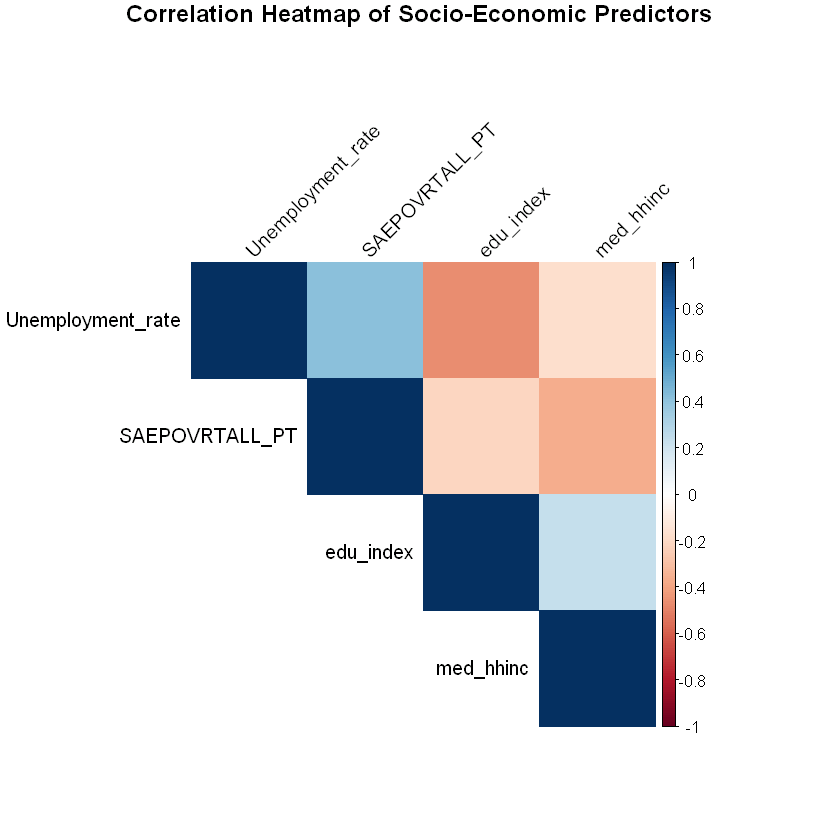

In [31]:
set.seed(1811)

corr_vars <- wis %>%
  dplyr::select(Unemployment_rate, SAEPOVRTALL_PT, edu_index, med_hhinc)
corr_matrix <- cor(corr_vars, use = "complete.obs")
corrplot(corr_matrix, method = "color", type = "upper", tl.col = "black", tl.srt = 45,
         title = "Correlation Heatmap of Socio-Economic Predictors", mar = c(0,0,1,0))


Warning message in ind1:ind2:
"numerical expression has 2 elements: only the first used"


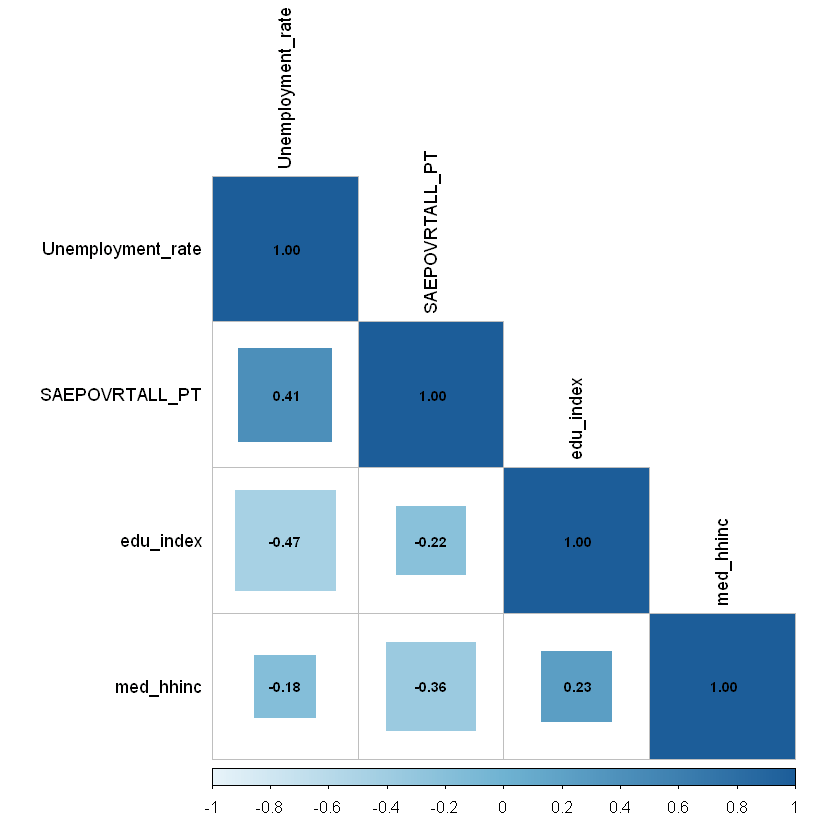

In [32]:
set.seed(1811)

corrplot(
  cor(corr_vars),
  method = 'square',
  type = 'lower',
  tl.col = 'black',
  tl.cex = 0.9,
  col = colorRampPalette(c("#e8f4fa", "#6fb3d2", "#1c5d99"))(200),
  addCoef.col = "black",
  number.cex = 0.7
)


- Size of the square represents strength of correlation. Purple color represents negative correlation, green represents positive correlation

## 2. Variable Selection

In [42]:
set.seed(1811)

#  Remove identifiers and unwanted columns
train_noid <- train %>%
dplyr::select(
  
  -county, -new_id, -judge_id, -wcisclass, -age_offense, -age_judge, -highest_severity, 
  -recid_180d, -zip, -pct_rural, -pct_urban, -pct_college, -pct_food_stamps, -pct_somecollege, 
  -year, -jail, -train_test_split_caselevel, -train_test_split_deflevel, 
  -max_hist_jail, -min_hist_jail, -avg_hist_jail, -median_hist_jail, 
  -all_races, -recid_180d_violent, -County_Name, -FIPS, -edu_year_cat, 
  -Percent.of.adults.who.are.not.high.school.graduates, 
  -Percent.of.adults.who.are.high.school.graduates..or.equivalent., 
  -Percent.of.adults.completing.some.college.or.associate.degree, 
  -Percent.of.adults.with.a.bachelor.s.degree.or.higher, 
  -Civilian_labor_force, -Employed, -Unemployed, 
  -total_priors, -age_group, -avg_pct_college, -avg_pct_somecollege, -edu_index2
)


#  Remove missing values
train_noid <- tidyr::drop_na(train_noid)

# Scale numeric values. 
train_noid_scaled <- train_noid %>%
  mutate(across(where(is.numeric), scale))


#  Remove columns that have only one unique value
train_noid <- train_noid[vapply(train_noid, function(x) length(unique(x)) > 1, logical(1))]

train_noid_sub <- train_noid[sample(1:nrow(train_noid), 0.3 * nrow(train_noid)), ]

head(train_noid_sub)

,sex,race,case_type,release,probation,is_recid_new,pct_black,pct_hisp,pct_male,pop_dens,⋯,Unemployment_rate,SAEPOVALL_PT,SAEPOVRTALL_PT,has_priors,has_jail_history,case_duration,total_prior_severity,edu_index,avg_year_pct_college,avg_year_pct_somecollege
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<fct>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>
122139,M,Caucasian,Misdemeanor,1,1,1,0.018618563,0.101022514,0.4961163,654.92196,⋯,9.1,11080,9.9,0,0,0,0,265.4244,0.2056542,0.2996286
41706,M,African American,Felony,0,0,0,0.118876166,0.703175540,0.5229135,4980.70865,⋯,8.7,5050,8.7,1,0,1,2,261.2837,0.2114296,0.3003352
140408,M,Hispanic,Criminal Traffic,1,0,0,0.005286504,0.130521966,0.4937109,89.33961,⋯,8.9,12699,12.8,0,0,0,0,270.9305,0.2456476,0.2948298
51697,M,Caucasian,Misdemeanor,0,0,0,0.006049549,0.095160361,0.4995199,57.54068,⋯,7.4,8145,10.1,1,0,0,0,267.4759,0.2387176,0.3079077
195943,M,Caucasian,Misdemeanor,0,0,1,0.002046385,0.008185539,0.5136426,16.21697,⋯,8.3,6952,11.4,1,1,0,3,261.2837,0.2126267,0.3015343
155865,M,Caucasian,Criminal Traffic,0,0,0,0.081263121,0.086117915,0.4847577,691.86095,⋯,3.5,51941,11.1,1,0,1,3,314.6225,0.4084649,0.2814485


### Forward Selection using BIC

In [43]:
set.seed(1811)
# Forward BIC
full = glm(is_recid_new ~ ., data=train_noid_sub,family='binomial'(link = "logit"),maxit=500)
minimum = glm(is_recid_new ~ 1, data=train_noid_sub,family='binomial'(link = "logit"), maxit=500)
n= nrow(train_noid_sub)
#AIC
fwd_AIC<-step(minimum, 
     scope = list(lower=minimum,upper = full), 
     direction = "forward", trace=F,k=log(n))
fwd_AIC


Call:  glm(formula = is_recid_new ~ has_priors + total_prior_severity + 
    case_duration + race + SAEPOVALL_PT + case_type + sex + pct_black + 
    med_hhinc + pct_hisp + Unemployment_rate + has_jail_history + 
    violent_crime + X2013.Rural.urban.Continuum.Code + pct_male, 
    family = binomial(link = "logit"), data = train_noid_sub, 
    maxit = 500)

Coefficients:
                          (Intercept)                            has_priors1  
                           -8.560e-01                              8.193e-01  
                 total_prior_severity                          case_duration  
                            3.030e-02                             -1.845e-01  
raceAmerican Indian or Alaskan Native          raceAsian or Pacific Islander  
                            1.298e-01                             -5.936e-01  
                        raceCaucasian                           raceHispanic  
                           -4.614e-01                             -4.021

The forward selection method using BIC chose the following predictors
- has_priors 
- total_prior_severity 
- case_duration 
- race
- SAEPOVALL_PT 
- case_type 
- sex
- pct_black  
- med_hhinc 
- pct_hisp 
- Unemployment_rate 
- has_jail_history  
- violent_crime 
- X2013.Rural.urban.Continuum.Code 
- pct_male

### LASSO

- Using a larger subset of coefficients for LASSO as it is faster and also using the entire data instead of a sub sample
- type.measure = "deviance". deviance measures model fit while class measures misclassification rate.

[1] 116270

[1] 116270

142 x 1 sparse Matrix of class "dgCMatrix"
                                                                s1
(Intercept)                                           4.927126e+01
sexM                                                  .           
raceAmerican Indian or Alaskan Native                 .           
raceAsian or Pacific Islander                         .           
raceCaucasian                                        -7.947237e-02
raceHispanic                                          .           
case_typeFelony                                      -1.554595e-01
case_typeMisdemeanor                                  6.302632e-02
wcisclass1st Deg. Sex. Assault of Child              -6.760763e-01
wcisclass2nd Deg. Sex. Assault of Child              -1.391330e+00
wcisclassArmed Robbery                               -1.735190e+00
wcisclassArson                                       -1.498301e+00
wcisclassBAC                                          8.797329e-01
wcisclassBail Jumpi

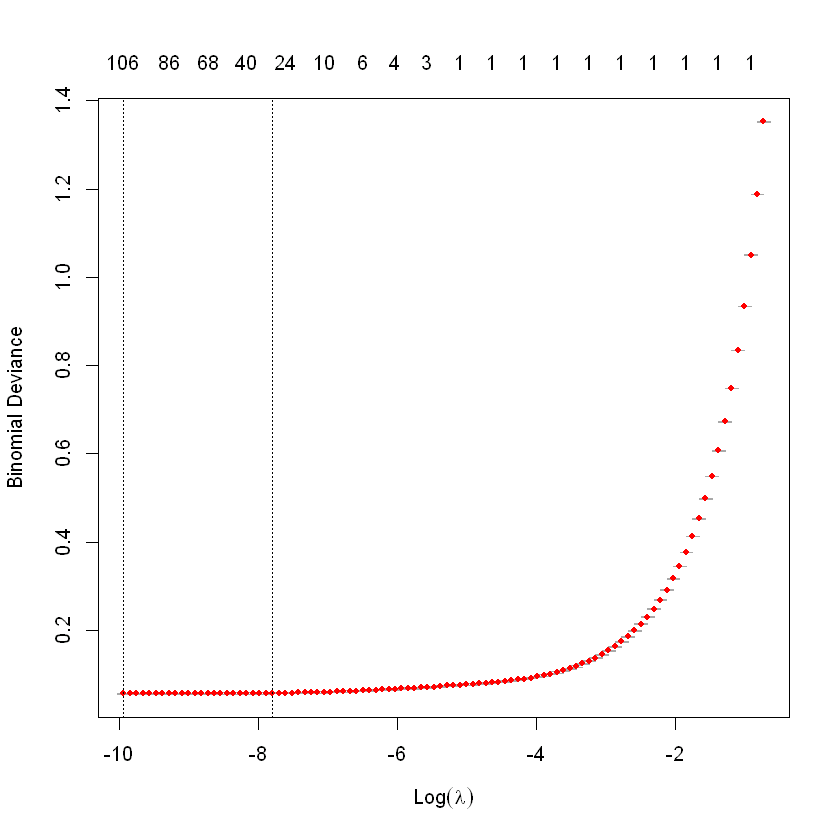

In [44]:
set.seed(1811)

# Make sure 'train' is a tibble
train <- as_tibble(train)

# Remove identifiers and unwanted columns
train_noid <- dplyr::select(
  train,
  -county, -new_id, -judge_id, -County_Name, -FIPS, -zip,
  -train_test_split_caselevel, -train_test_split_deflevel, -edu_year_cat,
    -Percent.of.adults.who.are.not.high.school.graduates   ,           
    -Percent.of.adults.who.are.high.school.graduates..or.equivalent.  ,          
    -Percent.of.adults.completing.some.college.or.associate.degree ,          
    -Percent.of.adults.with.a.bachelor.s.degree.or.higher ,
    -avg_pct_college, -avg_pct_somecollege
)

# Remove missing values
train_noid <- tidyr::drop_na(train_noid)

# Remove columns that have only one unique value
train_noid <- train_noid[vapply(train_noid, function(x) length(unique(x)) > 1, logical(1))]


#  Create model matrix
x <- model.matrix(is_recid_new ~ ., data = train_noid)[, -1]
y <- train_noid$is_recid_new


nrow(x); length(y)

#  Run LASSO with cross-validation
set.seed(1811)
cv_lasso <- cv.glmnet(x, y, family = "binomial", alpha = 1 ,standardize = TRUE) #alpha = 1 is LASSO and 0 is ridge
#Regularization methods need scaled predictors and reponses.
#By default 10-fold cross validation is done

# Plot
plot(cv_lasso)
coef(cv_lasso, s = "lambda.min")


In [45]:
set.seed(1811)
selected_names <- rownames(coef(cv_lasso, s = "lambda.min"))[
  coef(cv_lasso, s = "lambda.min")[,1] != 0
]
selected_names

[1] "(Intercept)"                                         
  [2] "raceCaucasian"                                       
  [3] "case_typeFelony"                                     
  [4] "case_typeMisdemeanor"                                
  [5] "wcisclass1st Deg. Sex. Assault of Child"             
  [6] "wcisclass2nd Deg. Sex. Assault of Child"             
  [7] "wcisclassArmed Robbery"                              
  [8] "wcisclassArson"                                      
  [9] "wcisclassBAC"                                        
 [10] "wcisclassBail Jumping"                               
 [11] "wcisclassBattery"                                    
 [12] "wcisclassBurglary"                                   
 [13] "wcisclassChild Abuse"                                
 [14] "wcisclassContempt of Court"                          
 [15] "wcisclassCrimes Against Children"                    
 [16] "wcisclassCriminal Damage"                            
 [17] "wcisclassCriminal Trespass"                          
 [18] "wcisclassDrug Paraphernalia"                         
 [19] "wcisclassDrug Possession"                            
 [20] "wcisclassEscape"                                     
 [21] "wcisclassForgery"                                    
 [22] "wcisclassFourth Degree Sexual Assau"                 
 [23] "wcisclassHit and Run"                                
 [24] "wcisclassIntimidate Witness/Victim"                  
 [25] "wcisclassNon-Traffic Forfeiture"                     
 [26] "wcisclassOAR/OAS"                                    
 [27] "wcisclassOperate Vehicle w/out Consent"              
 [28] "wcisclassOperate Vehicle Without Consent"            
 [29] "wcisclassOperate Without License"                    
 [30] "wcisclassOperating while intoxicated"                
 [31] "wcisclassOther Bodily Security"                      
 [32] "wcisclassOther Crimes Against Children"              
 [33] "wcisclassOther Felony"                               
 [34] "wcisclassOther Fraud"                                
 [35] "wcisclassOther Homicide"                             
 [36] "wcisclassOther Misdemeanor"                          
 [37] "wcisclassOther Public Safety Crimes"                 
 [38] "wcisclassPerjury"                                    
 [39] "wcisclassReceiving Stolen Property"                  
 [40] "wcisclassResisting Officer"                          
 [41] "wcisclassRetail Theft (Shoplifting)"                 
 [42] "wcisclassSexual Assault"                             
 [43] "wcisclassStalking"                                   
 [44] "wcisclassSubstantial/Aggravated Battery"             
 [45] "wcisclassTheft"                                      
 [46] "wcisclassUnarmed Robbery"                            
 [47] "wcisclassUnidentified Felony"                        
 [48] "wcisclassUnidentified Misdemeanor"                   
 [49] "wcisclassUnidentified Misdemeanor Traffic"           
 [50] "wcisclassWorthless Checks"                           
 [51] "age_offense"                                         
 [52] "age_judge"                                           
 [53] "release1"                                            
 [54] "probation1"                                          
 [55] "recid_180d"                                          
 [56] "pct_black"                                           
 [57] "pct_hisp"                                            
 [58] "pct_male"                                            
 [59] "pct_rural"                                           
 [60] "pct_urban"                                           
 [61] "pct_food_stamps"                                     
 [62] "pct_somecollege"                                     
 [63] "med_hhinc"                                           
 [64] "year"                                                
 [65] "jail"                                                
 [66] "max_hist_jail"                

These are the variables selected by LASSO:
- race, case_type, wcisclass, age_offense, age_judge, release, probation, has_priors, has_jail_history, recid_180d, recid_180d_violent, pct_black, pct_hisp, pct_male, pct_rural, pct_urban, pct_food_stamps, pct_somecollege, med_hhinc, Unemployment_rate, SAEPOVALL_PT, SAEPOVRTALL_PT, edu_index, avg_year_pct_somecollege, case_duration, total_priors, total_prior_severity, violent_crime, X2013.Urban.Influence.Code, X2013.Rural.urban.Continuum.Code, year
- A subset of these variables are also selected by forward selection(BIC).
- However these are still too many variables as I aim towards interpreting over prediction. I will be excluding the folloiwng variables from the above list for my analysis as it is either redundant(possible multicollinearity) or not interested in them:
    - wcisclass,
age_offense,
age_judge,
pct_rural,
pct_urban,
pct_food_stamps,
pct_somecollege,
SAEPOVALL_PT,
avg_year_pct_somecollege,
total_priors,
total_prior_severity


- Final list of variables selected:
  - race
  - case_type
  - release
  - probation
  - has_priors
  - has_jail_history
  - pct_black
  - pct_hisp
  - pct_male
  - med_hhinc
  - Unemployment_rate
  - SAEPOVRTALL_PT
  - edu_index
  - case_duration
  - violent_crime
  - X2013.Urban.Influence.Code
  - age_group
  - total_prior_severity




## 3. Logistic Model

#### Model build

In [47]:
set.seed(1811)

# Fit Logistic Regression Model using only LASSO-selected predictors
model1 <- glm(
  is_recid_new ~ 
    race  + case_type + release + probation +
    has_priors + has_jail_history +
    pct_black + pct_hisp + pct_male +
    med_hhinc + Unemployment_rate +
    SAEPOVRTALL_PT + edu_index +
    case_duration + violent_crime +
    X2013.Urban.Influence.Code + age_group,
  data = train,
  family = binomial(link = "logit")
)

# View model summary
summary(model1)



Call:
glm(formula = is_recid_new ~ race + case_type + release + probation + 
    has_priors + has_jail_history + pct_black + pct_hisp + pct_male + 
    med_hhinc + Unemployment_rate + SAEPOVRTALL_PT + edu_index + 
    case_duration + violent_crime + X2013.Urban.Influence.Code + 
    age_group, family = binomial(link = "logit"), data = train)

Coefficients:
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                           -8.946e-01  1.233e-01  -7.254 4.06e-13
raceAmerican Indian or Alaskan Native  8.371e-02  2.358e-02   3.550 0.000385
raceAsian or Pacific Islander         -5.551e-01  4.557e-02 -12.182  < 2e-16
raceCaucasian                         -3.824e-01  1.330e-02 -28.760  < 2e-16
raceHispanic                          -4.224e-01  1.917e-02 -22.031  < 2e-16
case_typeFelony                       -2.022e-01  1.349e-02 -14.984  < 2e-16
case_typeMisdemeanor                   6.869e-02  1.113e-02   6.171 6.77e-10
release1                

- Urban Influence Codes and probation lack statistical significance as they have larger p-values. Other variables seem to be statistically significant. 
- It was observed in my EDA that Education, Unemployment and poverty all have some correlation. Perhaps replacing these with an interaction term might help.

####  Model evaluation

[1] "Model performance including subset of LASSO predictors:"


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Model Evaluation Summary
---------------------------------
AUC: 0.672 
Accuracy: 0.645 
Precision: 0.577 
Sensitivity (Recall): 0.366 
Specificity: 0.826 



$AUC
Area under the curve: 0.672

$Accuracy
 Accuracy 
0.6452786 

$Precision
Pos Pred Value 
      0.577378 

$Sensitivity
Sensitivity 
  0.3659473 

$Specificity
Specificity 
   0.826357 

$ConfusionMatrix
Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 57469 28585
         1 12076 16498
                                         
               Accuracy : 0.6453         
                 95% CI : (0.6425, 0.648)
    No Information Rate : 0.6067         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.2055         
                                         
 Mcnemar's Test P-Value : < 2.2e-16      
                                         
            Sensitivity : 0.3659         
            Specificity : 0.8264         
         Pos Pred Value : 0.5774         
         Neg Pred Value : 0.6678         
             Prevalence : 0.3933         
         Detection Rate : 0.1439        

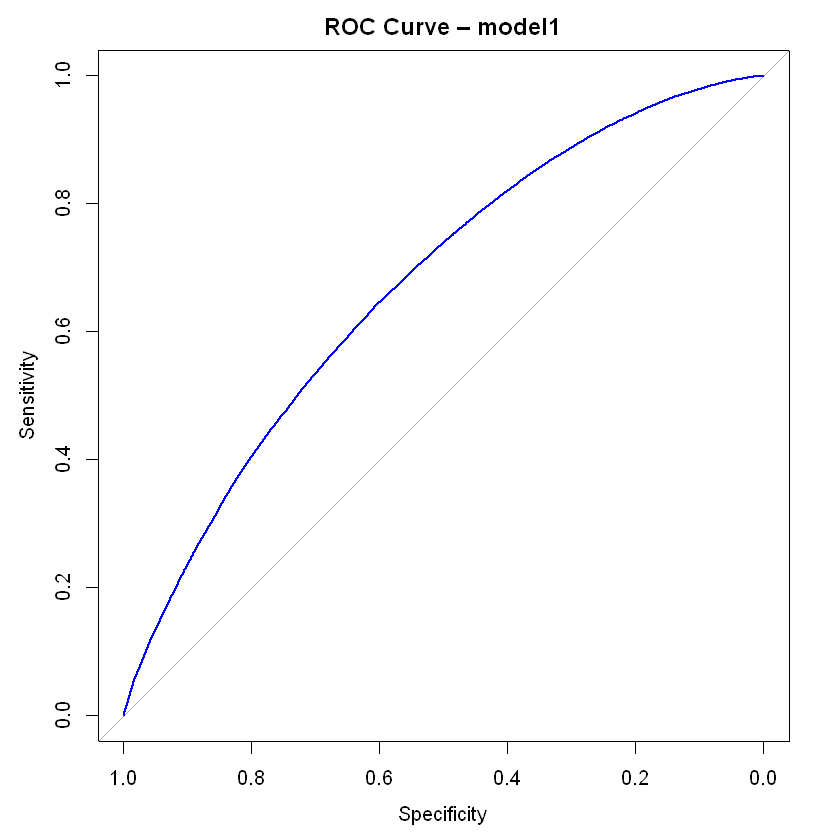

In [12]:
set.seed(1811)


print("Model performance including subset of LASSO predictors:")
result_basic <- evaluate_model(model1,test)
result_basic

- The Sensitivity is only 0.366 and Specificity is high which means that the model correctly identifies non-recidivists most of the time and misses identifying recidivists.

#### Statistical Inference for model1

#### Testing Overall regression

In [48]:
set.seed(1811)
gstat = model1$null.deviance - deviance(model1)
cbind(gstat, 1-pchisq(gstat,length(coef(model1)-1)))

gstat,
24064.25,0


- We can reject the Null Hypothesis that all regression coefficients are 0 and conclude that atleast one of them is significant.

#### Testing inflated p-value problem and Multicollinearity Check

In [49]:
set.seed(1811)
vif(model1)

,GVIF,Df,GVIF^(1/(2*Df))
race,2.034943,4,1.092871
case_type,1.489592,2,1.104757
release,1.500540,1,1.224965
probation,1.739703,1,1.318978
has_priors,1.097174,1,1.047461
has_jail_history,1.149552,1,1.072171
pct_black,2.511408,1,1.584742
pct_hisp,1.338083,1,1.156755
pct_male,1.114639,1,1.055765
med_hhinc,1.745344,1,1.321114


In [50]:
set.seed(1811)
#psuedo R-squared for logistic reg
r2_model <- 1 - (model1$deviance / model1$null.deviance)
r2_model
VIF_thresh <- max(10,1/(1-r2_model))
print(paste("Threshold VIF:",VIF_thresh))

[1] 0.06740495

[1] "Threshold VIF: 10"


- All VIF's are below the threshold value indicating no sign of multicollinearity

#### Sub sampling approach to identify inflated p-value

- When we have a large sample size, we could have an inflated p-value problem. Hence sub sampling approach has been used to identify how consistently low the p-values are for the individual predictors

Running subsample test for 20% ...

Running subsample test for 30% ...



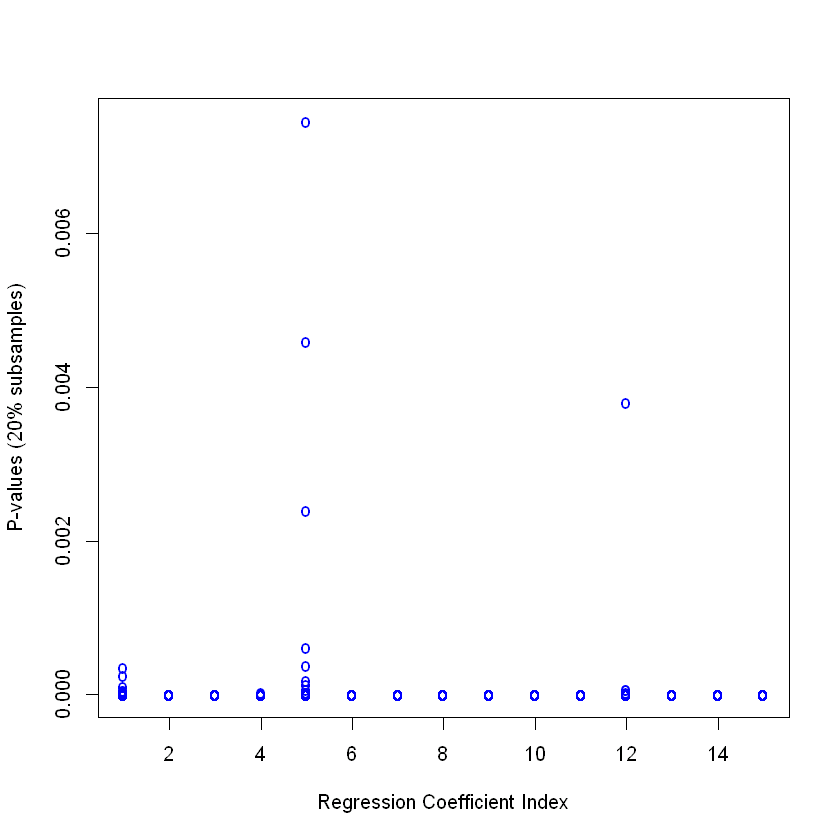

,Coefficient,Estimate,Pvalue,Freq,Subsample
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
raceAsian or Pacific Islander...1,raceAsian or Pacific Islander,-6.056600e-01,1.069287e-09,100,20%
raceCaucasian...2,raceCaucasian,-3.932989e-01,6.113646e-40,100,20%
raceHispanic...3,raceHispanic,-4.848095e-01,2.379224e-29,100,20%
case_typeFelony...4,case_typeFelony,-1.930693e-01,1.571779e-10,100,20%
release1...5,release1,-1.349771e-01,2.604751e-08,100,20%
has_priors1...6,has_priors1,9.361756e-01,0.000000e+00,100,20%
has_jail_history1...7,has_jail_history1,4.045517e-01,4.606324e-60,100,20%
pct_black...8,pct_black,-8.859154e-01,1.336246e-31,100,20%
pct_hisp...9,pct_hisp,-8.490912e-01,4.409929e-16,100,20%


,Coefficient,Estimate,Pvalue,Freq,Subsample
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),(Intercept),-0.8398162205,2.578615e-03,82,20%
raceAmerican Indian or Alaskan Native...2,raceAmerican Indian or Alaskan Native,0.1139671029,3.195874e-02,18,20%
case_typeMisdemeanor...3,case_typeMisdemeanor,0.0754028290,2.458563e-03,62,20%
probation1...4,probation1,0.0009982275,9.688289e-01,3,20%
Unemployment_rate...5,Unemployment_rate,-0.0197615899,5.156573e-04,50,20%
SAEPOVRTALL_PT...6,SAEPOVRTALL_PT,-0.0032457863,2.574340e-01,13,20%
edu_index...7,edu_index,0.0007016205,2.985365e-01,1,20%
X2013.Urban.Influence.Code3...8,X2013.Urban.Influence.Code3,0.0300042128,5.369966e-01,0,20%
X2013.Urban.Influence.Code4...9,X2013.Urban.Influence.Code4,0.1641323564,9.056768e-02,0,20%


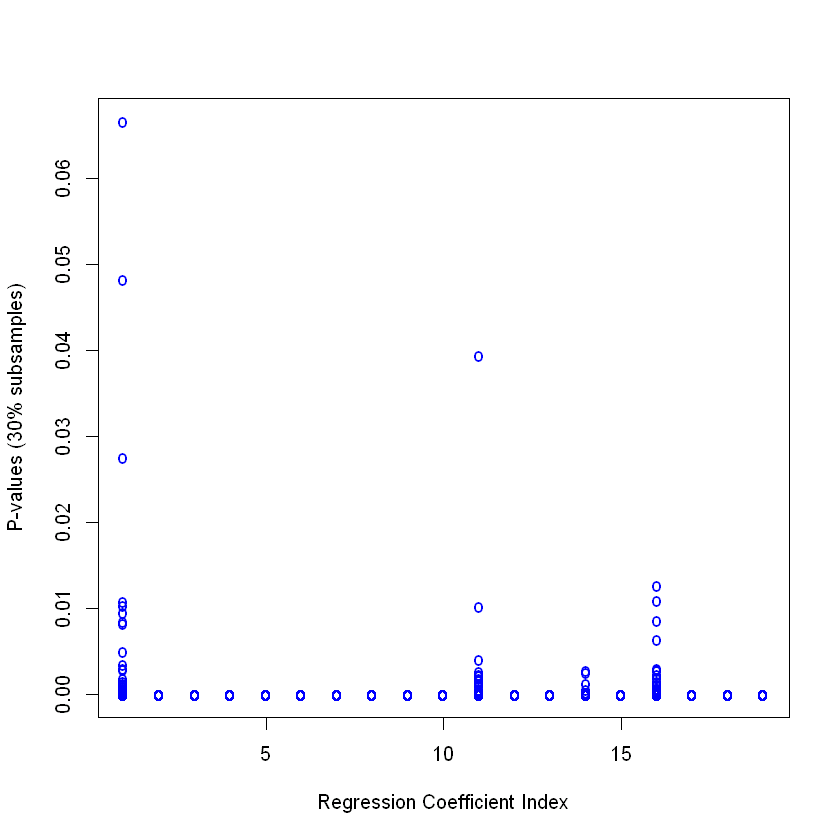

In [51]:
set.seed(1811)

# Define parameters
n <- nrow(train)
B <- 100              # Number of times to subsample
alph <- 0.01          # Significance threshold
perc_list <- c(0.2, 0.3)  # Percentages to test

# Store results for each percentage
results_list <- list()

results_list_insif <- list()

# Loop over each subsampling percentage
for (perc in perc_list) {
  message("Running subsample test for ", perc * 100, "% ...")
  
  count <- 1
  ncoef <- dim(summary(model1)$coeff)[1]
  pv_matrix <- matrix(0, nrow = ncoef, ncol = B)
  
  # Repeat B subsamples
  while (count <= B) {
    subsample <- sample(n, floor(n * perc), replace = FALSE)
    subdata <- train[subsample, ]
    
    # Fit logistic model on subsample
    submod <- glm(
      is_recid_new ~ race  + case_type + release + probation +
    has_priors + has_jail_history +
    pct_black + pct_hisp + pct_male +
    med_hhinc + Unemployment_rate +
    SAEPOVRTALL_PT + edu_index +
    case_duration + violent_crime +
    X2013.Urban.Influence.Code  + age_group,
      data = subdata,
      family = binomial
    )
    
    # Store p-values
    pv_matrix[, count] <- summary(submod)$coeff[, 4]
    count <- count + 1
  }
  
  # Calculate frequency of significant coefficients
  pv_significant <- rowSums(pv_matrix <= alph)
  
  # Identify stable coefficients (significant in ≥95 of 100 subsamples)
  idx_scoef <- which(pv_significant >= 95)
    
     # Identify stable coefficients (significant in ≥95 of 100 subsamples)
  idx_scoef2 <- which(pv_significant <= 85)
  
  # Store summarized result
  result_df1 <- data.frame(
    Coefficient = rownames(summary(submod)$coeff)[idx_scoef],
    Estimate = summary(submod)$coeff[idx_scoef, 1],
    Pvalue = summary(submod)$coeff[idx_scoef, 4],
    Freq = pv_significant[idx_scoef],
    Subsample = paste0(perc * 100, "%")
  )
    
      # Store summarized result
  result_df2 <- data.frame(
    Coefficient = rownames(summary(submod)$coeff)[idx_scoef2],
    Estimate = summary(submod)$coeff[idx_scoef2, 1],
    Pvalue = summary(submod)$coeff[idx_scoef2, 4],
    Freq = pv_significant[idx_scoef2],
    Subsample = paste0(perc * 100, "%")
  )
  
  results_list[[as.character(perc)]] <- result_df1
    results_list_insif[[as.character(perc)]] <- result_df2
  
  # Plot p-value dispersion for significant coefficients
  matplot(pv_matrix[idx_scoef, ],
          xlab = "Regression Coefficient Index",
          ylab = paste("P-values (", perc*100, "% subsamples)", sep=""),
          type = "p", pch = "o", col = "blue")
}

# Combine all results
stability_summary <- bind_rows(results_list)
stability_summary_insif <- bind_rows(results_list_insif)

# View final stable coefficients across all subsampling levels
stability_summary

stability_summary_insif 




- Subsampling approach for 20 and 30% of data was done for 100 iterations to see the real significance of p-values.
- Empirical distribution of p-value is not uniform. Hence, there is absence of inflation of statitistical significance.
- However some variables edu_index, case_Type, unemployment and poverty has sometimes shown lower statistical significance. Other variables seem to be consistently showing lower p-values. This could be due to the fact that it is correlated with median household income and Urban Influence codes.
- An interaction of the three socio-economic variables could make a difference and removal of Urban Influence codes.
- Probation and release have high correlation. Removing one could help.

## 4. Logistic model with Interaction term

#### Model Building

#### Checking interaction between poverty, Education and unemployment

In [14]:

# INTERACTION ANALYSIS: EDUCATION × POVERTY × UNEMPLOYMENT


set.seed(1811)

# Fit Logistic Regression Model using only LASSO-selected predictors
model_interact <- glm(
  is_recid_new ~ 
    Unemployment_rate*SAEPOVRTALL_PT*edu_index +
    race  + case_type + release + 
    has_priors + has_jail_history +
    pct_black + pct_hisp + pct_male +
    med_hhinc  +
    case_duration + violent_crime +
    age_group,
  data = train,
  family = binomial(link = "logit")
)

# View model summary
summary(model_interact)


Call:
glm(formula = is_recid_new ~ Unemployment_rate * SAEPOVRTALL_PT * 
    edu_index + race + case_type + release + has_priors + has_jail_history + 
    pct_black + pct_hisp + pct_male + med_hhinc + case_duration + 
    violent_crime + age_group, family = binomial(link = "logit"), 
    data = train)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                 1.634e+00  7.319e-01   2.233
Unemployment_rate                          -3.787e-02  1.031e-01  -0.367
SAEPOVRTALL_PT                             -2.945e-01  6.123e-02  -4.810
edu_index                                  -8.240e-03  2.633e-03  -3.129
raceAmerican Indian or Alaskan Native       9.895e-02  2.272e-02   4.355
raceAsian or Pacific Islander              -5.457e-01  4.555e-02 -11.979
raceCaucasian                              -3.864e-01  1.327e-02 -29.128
raceHispanic                               -4.234e-01  1.916e-02 -22.102
case_typeFelony         

[1] "Model performance including interaction term predictors:"


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Model Evaluation Summary
---------------------------------
AUC: 0.672 
Accuracy: 0.644 
Precision: 0.576 
Sensitivity (Recall): 0.362 
Specificity: 0.827 



$AUC
Area under the curve: 0.6715

$Accuracy
 Accuracy 
0.6443888 

$Precision
Pos Pred Value 
     0.5761905 

$Sensitivity
Sensitivity 
  0.3623317 

$Specificity
Specificity 
  0.8272342 

$ConfusionMatrix
Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 57530 28748
         1 12015 16335
                                          
               Accuracy : 0.6444          
                 95% CI : (0.6416, 0.6472)
    No Information Rate : 0.6067          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.2028          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.3623          
            Specificity : 0.8272          
         Pos Pred Value : 0.5762          
         Neg Pred Value : 0.6668          
             Prevalence : 0.3933          
         Detection Rate 

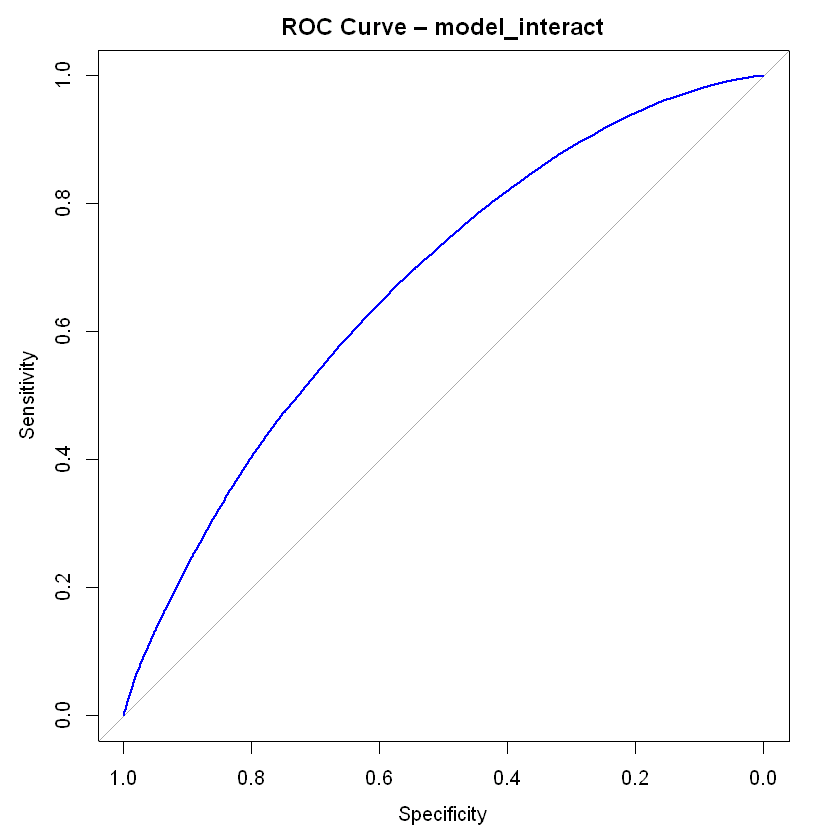

In [53]:
set.seed(1811)
print("Model performance including interaction term predictors:")
evaluate_model(model_interact,test)

- **Interaction between education and Poverty:**

When both education attaintment and poverty increases together there is a 0.11% increase in odds of recidivism indicating that increase in education tones down the effect of increase in poverty on recidivism.
- **Interaction between education and Unemployment:**
This is not statistically significant as per the model.
When both education attaintment and unemployment increases together there is a 0.01% increase in odds of recidivism indicating that increase in education tones down the effect of increase in unemployment on recidivism.
- **Interaction between poverty and Unemployment:**

This is not statistically significant.An increase in poverty and unemployment increases the odds of recidivism by almost 1.4%

- **Education:**

Education reduces risk of recidivism by 0.8%


#### A more reduced model with the interaction term

In [48]:
# Interaction model reduced

set.seed(1811)

# Fit Logistic Regression Model using only LASSO-selected predictors
# Also replacing has_priors with total_priors
model_interact_reduced <- glm(
  is_recid_new ~ 
    Unemployment_rate*SAEPOVRTALL_PT*edu_index +
    race  + case_type +
    total_priors + has_jail_history  + release +
     violent_crime + age_group,
  data = train,
  family = binomial(link = "logit")
)

# View model summary
summary(model_interact_reduced)


Call:
glm(formula = is_recid_new ~ Unemployment_rate * SAEPOVRTALL_PT * 
    edu_index + race + case_type + total_priors + has_jail_history + 
    release + violent_crime + age_group, family = binomial(link = "logit"), 
    data = train)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                 5.262e+00  7.287e-01   7.221
Unemployment_rate                          -2.614e-01  1.037e-01  -2.522
SAEPOVRTALL_PT                             -6.502e-01  6.079e-02 -10.696
edu_index                                  -2.134e-02  2.629e-03  -8.116
raceAmerican Indian or Alaskan Native       2.815e-01  2.163e-02  13.016
raceAsian or Pacific Islander              -3.541e-01  4.488e-02  -7.889
raceCaucasian                              -2.158e-01  1.155e-02 -18.683
raceHispanic                               -2.851e-01  1.815e-02 -15.708
case_typeFelony                            -2.571e-01  1.253e-02 -20.519
case_typeMisdeme

- **Interaction between education and Poverty:**

When both education attaintment and poverty increases together there is a 0.24% increase in odds of recidivism indicating that increase in education slightly weakens the effect of increase in poverty on recidivism.
- **Interaction between education and Unemployment:**

When both education attaintment and unemployment increases together there is a 0.1% increase in odds of recidivism indicating that increase in education tones down the effect of increase in unemployment on recidivism.
- **Interaction between poverty and Unemployment:**

An increase in poverty and unemployment increases the odds of recidivism by almost 5%

- **Education:**

Education reduces risk of recidivism by 2.11%

Overall this model explains recidivism better than the previous interaction model in terms of socio economic factors


#### Model Evaluation

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Model Evaluation Summary
---------------------------------
AUC: 0.672 
Accuracy: 0.644 
Precision: 0.576 
Sensitivity (Recall): 0.362 
Specificity: 0.827 



Setting levels: control = 0, case = 1

Setting direction: controls < cases



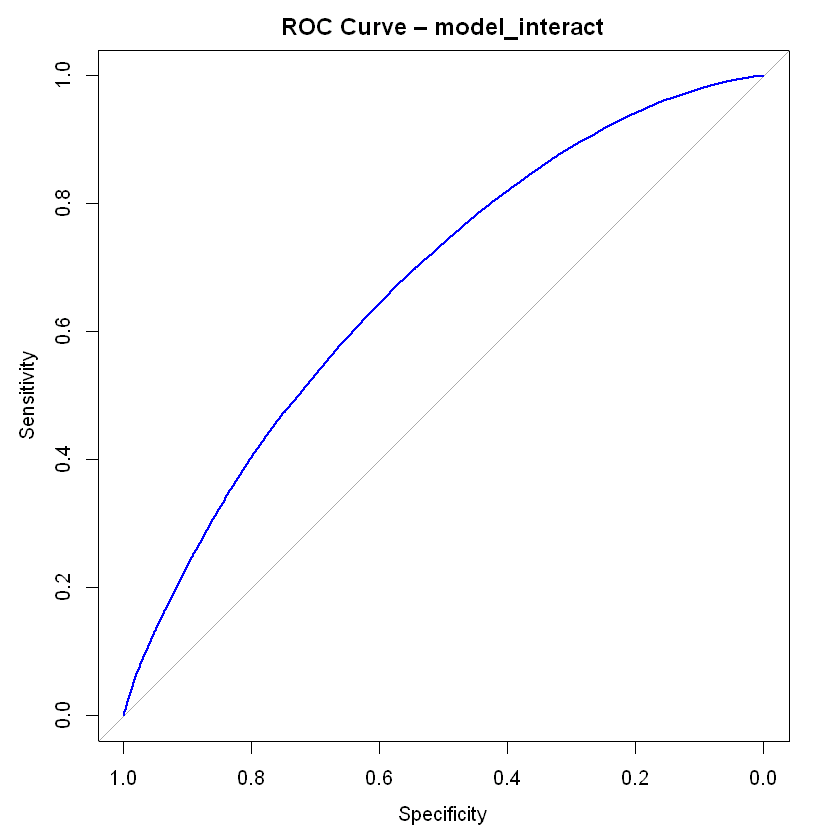

Model Evaluation Summary
---------------------------------
AUC: 0.687 
Accuracy: 0.659 
Precision: 0.623 
Sensitivity (Recall): 0.334 
Specificity: 0.869 



$AUC
Area under the curve: 0.6715

$Accuracy
 Accuracy 
0.6443888 

$Precision
Pos Pred Value 
     0.5761905 

$Sensitivity
Sensitivity 
  0.3623317 

$Specificity
Specificity 
  0.8272342 

$ConfusionMatrix
Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 57530 28748
         1 12015 16335
                                          
               Accuracy : 0.6444          
                 95% CI : (0.6416, 0.6472)
    No Information Rate : 0.6067          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.2028          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.3623          
            Specificity : 0.8272          
         Pos Pred Value : 0.5762          
         Neg Pred Value : 0.6668          
             Prevalence : 0.3933          
         Detection Rate 

$AUC
Area under the curve: 0.6868

$Accuracy
 Accuracy 
0.6587309 

$Precision
Pos Pred Value 
     0.6234987 

$Sensitivity
Sensitivity 
  0.3339396 

$Specificity
Specificity 
  0.8692789 

$ConfusionMatrix
Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 60454 30028
         1  9091 15055
                                         
               Accuracy : 0.6587         
                 95% CI : (0.656, 0.6615)
    No Information Rate : 0.6067         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.2213         
                                         
 Mcnemar's Test P-Value : < 2.2e-16      
                                         
            Sensitivity : 0.3339         
            Specificity : 0.8693         
         Pos Pred Value : 0.6235         
         Neg Pred Value : 0.6681         
             Prevalence : 0.3933         
         Detection Rate : 0.1313       

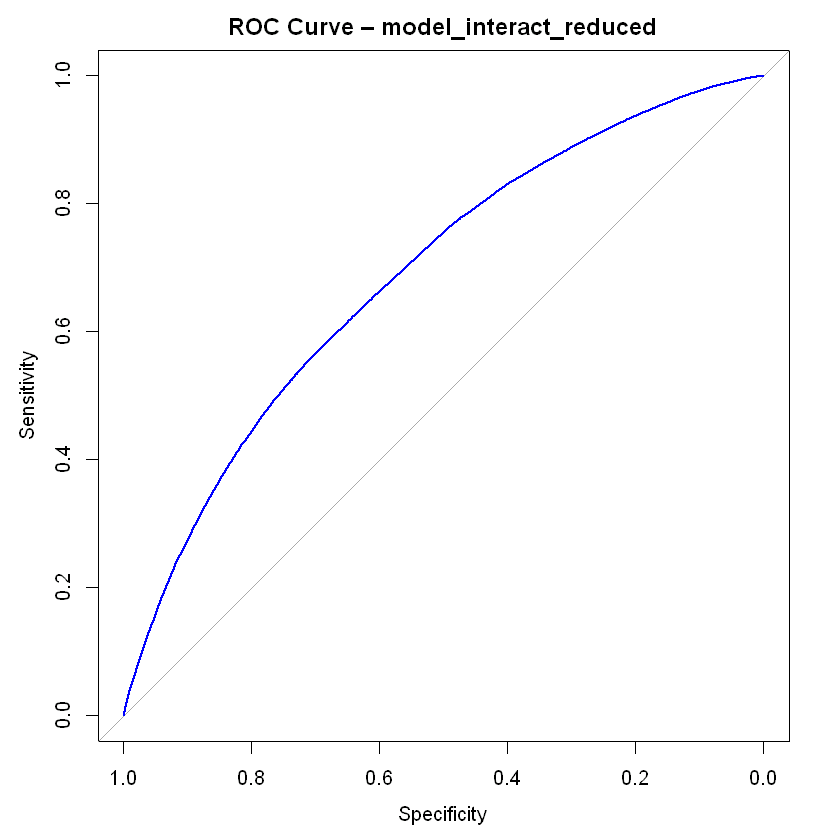

In [34]:
set.seed(1811)
result_interact <- evaluate_model(model_interact,test)
result_reduced <- evaluate_model(model_interact_reduced,test)
result_interact
result_reduced

#### Comparison between both the interaction models
- There is slightly better performance observed in the reduced interaction model and after replacing hs_priors with total_priors. The AUC value is 0.687 as opposed to the full interaction model's AUC which was 0.672.

#### Base model Vs Interaction Model
- The accuracy is slightly better in the interaction model and the interaction model is more interpretible in terms of socio-economic factors.

#### Statistical inference of interaction model

In [56]:
set.seed(1811)
gstat = model_interact_reduced$null.deviance - deviance(model_interact_reduced)
cbind(gstat, 1-pchisq(gstat,length(coef(model_interact_reduced)-1)))

gstat,
26605.2,0


#### WALD TEST: Does adding the interaction of edu X Poverty X unemployment add explanatory power?

In [57]:
set.seed(1811)
coef(model_interact_reduced)

(Intercept) 
                              5.2622664243 
                         Unemployment_rate 
                             -0.2614375807 
                            SAEPOVRTALL_PT 
                             -0.6502036748 
                                 edu_index 
                             -0.0213397507 
     raceAmerican Indian or Alaskan Native 
                              0.2815092161 
             raceAsian or Pacific Islander 
                             -0.3540518736 
                             raceCaucasian 
                             -0.2157736475 
                              raceHispanic 
                             -0.2851434714 
                           case_typeFelony 
                             -0.2570871643 
                      case_typeMisdemeanor 
                              0.0486748569 
                              total_priors 
                              0.1378649064 
                         has_jail_history1 
                              0.0248301546 
                                  release1 
                             -0.1040536208 
                             violent_crime 
                             -0.0682229738 
                         age_group35_to_49 
                             -0.2448764220 
                          age_group50_plus 
                             -0.6022161228 
                         age_groupUnder_25 
                              0.5641508447 
          Unemployment_rate:SAEPOVRTALL_PT 
                              0.0466975754 
               Unemployment_rate:edu_index 
                              0.0009666937 
                  SAEPOVRTALL_PT:edu_index 
                              0.0023746643 
Unemployment_rate:SAEPOVRTALL_PT:edu_index 
                             -0.0001785861

In [58]:

set.seed(1811)

# Wald test

# Education
print("Education alone:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "edu_index")
)

# Unemployment
print("Unemployment_rate alone:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "Unemployment_rate")
)

# Poverty
print("Poverty alone:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "SAEPOVRTALL_PT")
)

# Unemployment × Poverty

print("Unemployment × Poverty:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "Unemployment_rate:SAEPOVRTALL_PT")
)

#Unemployment × Education

print("Unemployment × Education:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "Unemployment_rate:edu_index")
)

# Poverty × Education

print("Poverty × Education:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) == "SAEPOVRTALL_PT:edu_index")
)

# All interactions combined (including 3-way)
print("Poverty × Education x Unemployment:")

wald.test(
  b = coef(model_interact_reduced),
  Sigma = vcov(model_interact_reduced),
  Terms = which(names(coef(model_interact_reduced)) %in% c(
    "Unemployment_rate:SAEPOVRTALL_PT",
    "Unemployment_rate:edu_index",
    "SAEPOVRTALL_PT:edu_index",
    "Unemployment_rate:SAEPOVRTALL_PT:edu_index"
  ))
)




[1] "Education alone:"


Wald test:
----------

Chi-squared test:
X2 = 65.9, df = 1, P(> X2) = 4.4e-16

[1] "Unemployment_rate alone:"


Wald test:
----------

Chi-squared test:
X2 = 6.4, df = 1, P(> X2) = 0.012

[1] "Poverty alone:"


...

Wald test:
----------

Chi-squared test:
X2 = 6.5, df = 1, P(> X2) = 0.011

[1] "Poverty × Education:"


Wald test:
----------

Chi-squared test:
X2 = 116.3, df = 1, P(> X2) = 0.0

[1] "Poverty × Education x Unemployment:"


Wald test:
----------

Chi-squared test:
X2 = 405.4, df = 4, P(> X2) = 0.0

- Adding socio-economic factors like education level, unrmployment and poverty does add statistical significance. Unemployment alone and interaction of Unemployment and Education has slightly higher p-value but still statistically significant at 0.05 level.

## 5. Outlier detection

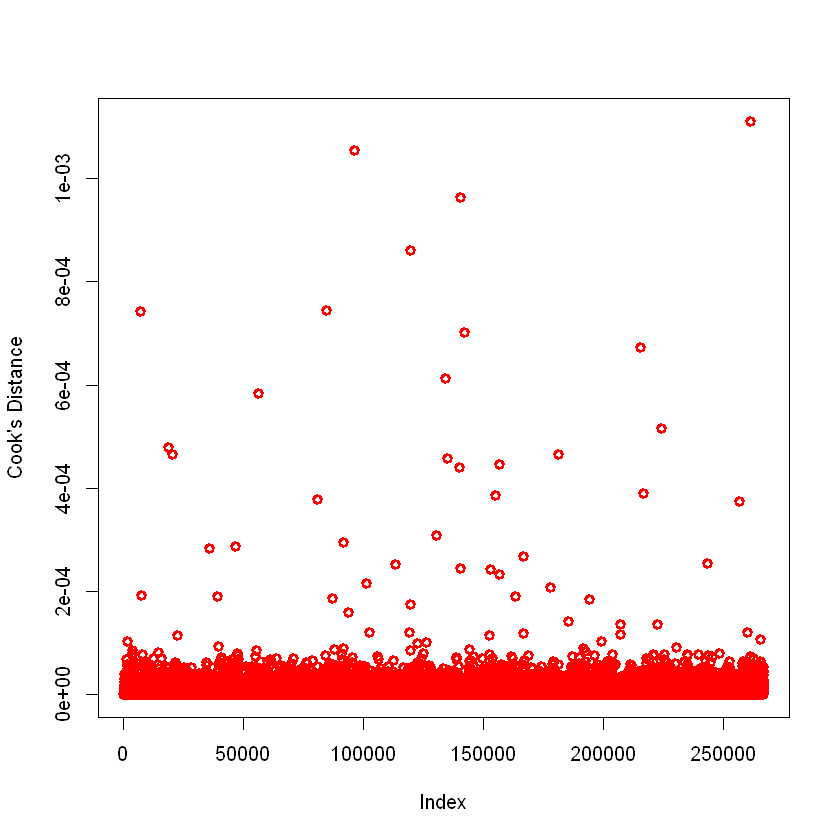

In [49]:
set.seed(1811)

cook_dist <- cooks.distance(model_interact_reduced)
# If Cook's distance is larger than 4/n then, it means there are outliers
#cook_thresh <- 4/nrow(train) # too strict
cook_thresh <- 0.01 #or # 0.5
plot(cook_dist,lwd=3,col="red", ylab = "Cook's Distance")
abline(h = cook_thresh, col = "black", lty = 2)

In [50]:
set.seed(1811)

# Count how many are above threshold
num_above <- (sum(cook_dist > cook_thresh)/nrow(train)) * 100
cat("% of observations above Cook’s D threshold:", num_above, "\n")
#which(cook_dist > cook_thresh)[1:20]  # first 20 most influential

% of observations above Cook’s D threshold: 0 


- No influencial outliers detected

#### Standardized-Residual Outlier Detection Using a Normal Quantile Cutoff

In [51]:
set.seed(1811)
dev_residuals <- residuals(model_interact_reduced, type ="deviance")
outliers <- which(abs(dev_residuals) > qnorm(.99995))
length(outliers)

[1] 0

## 6.  Goodness of Fit

- The Goodness of fit cannot be done for the dataset I have chosen as the response is binary outcome without replications(Bernoulli).
- Hence, I will not be performing goodness of fit.

## 7. Cross-Validation model with interaction

In [62]:
set.seed(1811)  # for reproducibility


train$is_recid_new <- as.factor(train$is_recid_new)
levels(train$is_recid_new ) <- c("Class0", "Class1")


ctrl <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = TRUE
)

modelcv <- caret::train(is_recid_new ~  Unemployment_rate*SAEPOVRTALL_PT*edu_index +
    race  + case_type +
    total_priors + has_jail_history  + release +
     violent_crime + age_group,
data = train,
method = "glm",
trControl = ctrl,
metric = "ROC")

print(modelcv)

Generalized Linear Model 

266677 samples
    10 predictor
     2 classes: 'Class0', 'Class1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 240009, 240010, 240010, 240010, 240009, 240010, ... 
Resampling results:

  ROC        Sens       Spec     
  0.6861233  0.8699392  0.3314075



In [86]:
set.seed(1811)

test$is_recid_new <- as.factor(test$is_recid_new)
levels(test$is_recid_new ) <- c("Class0", "Class1")

# Predictions
pred_class <- predict(modelcv, newdata = test)
pred_prob  <- predict(modelcv, newdata = test, type = "prob")[, "Class1"]


# Confusion Matrix
cm <- confusionMatrix(pred_class, test$is_recid_new)
cm
roc_obj <- roc(test$is_recid_new, pred_prob)
auc_val <- auc(roc_obj)
auc_val



Confusion Matrix and Statistics

          Reference
Prediction Class0 Class1
    Class0  60454  30028
    Class1   9091  15055
                                         
               Accuracy : 0.6587         
                 95% CI : (0.656, 0.6615)
    No Information Rate : 0.6067         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.2213         
                                         
 Mcnemar's Test P-Value : < 2.2e-16      
                                         
            Sensitivity : 0.8693         
            Specificity : 0.3339         
         Pos Pred Value : 0.6681         
         Neg Pred Value : 0.6235         
             Prevalence : 0.6067         
         Detection Rate : 0.5274         
   Detection Prevalence : 0.7894         
      Balanced Accuracy : 0.6016         
                                         
       'Positive' Class : Class0         
                                

Setting levels: control = Class0, case = Class1

Setting direction: controls < cases



Area under the curve: 0.6868

Confusion Matrix and Statistics

          Reference
Prediction Class0 Class1
    Class0  68354  42142
    Class1   1191   2941
                                          
               Accuracy : 0.622           
                 95% CI : (0.6192, 0.6248)
    No Information Rate : 0.6067          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.0573          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.98287         
            Specificity : 0.06524         
         Pos Pred Value : 0.61861         
         Neg Pred Value : 0.71176         
             Prevalence : 0.60670         
         Detection Rate : 0.59631         
   Detection Prevalence : 0.96395         
      Balanced Accuracy : 0.52405         
                                          
       'Positive' Class : Class0          
            

Setting levels: control = Class0, case = Class1

Setting direction: controls < cases



Area under the curve: 0.6664

- Positive Class is Class0, Hence Sensitivity and Specificity is reversed.

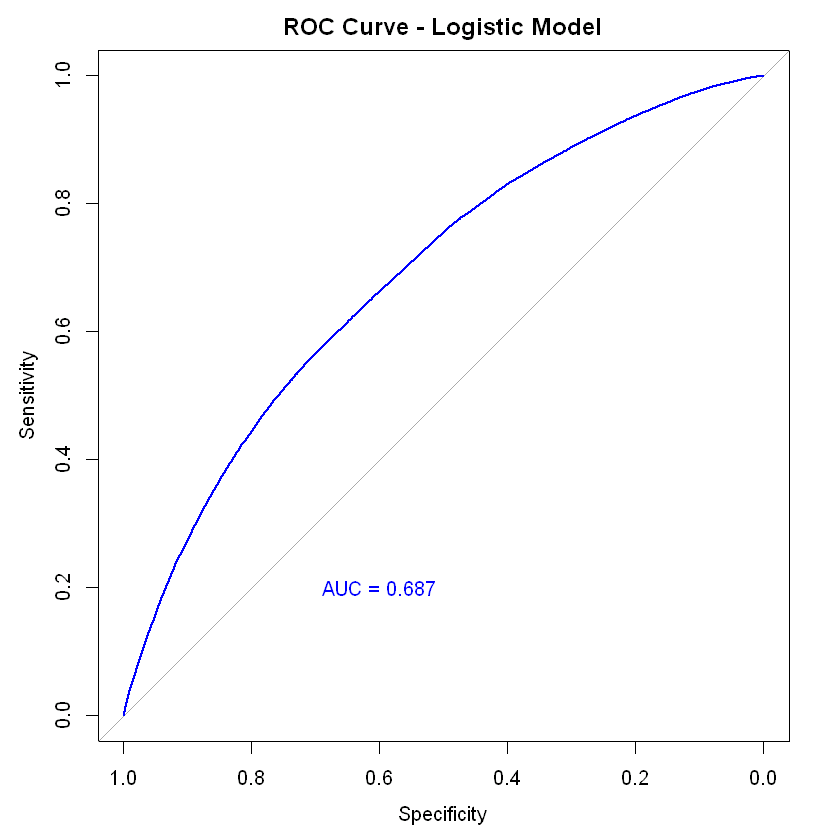

In [64]:
set.seed(1811)
plot(roc_obj, col = "blue", lwd = 2, main = "ROC Curve - Logistic Model")
text(0.6, 0.2, paste("AUC =", round(auc_val, 3)), col = "blue")


### Comparing accuracies and AUC of the three models

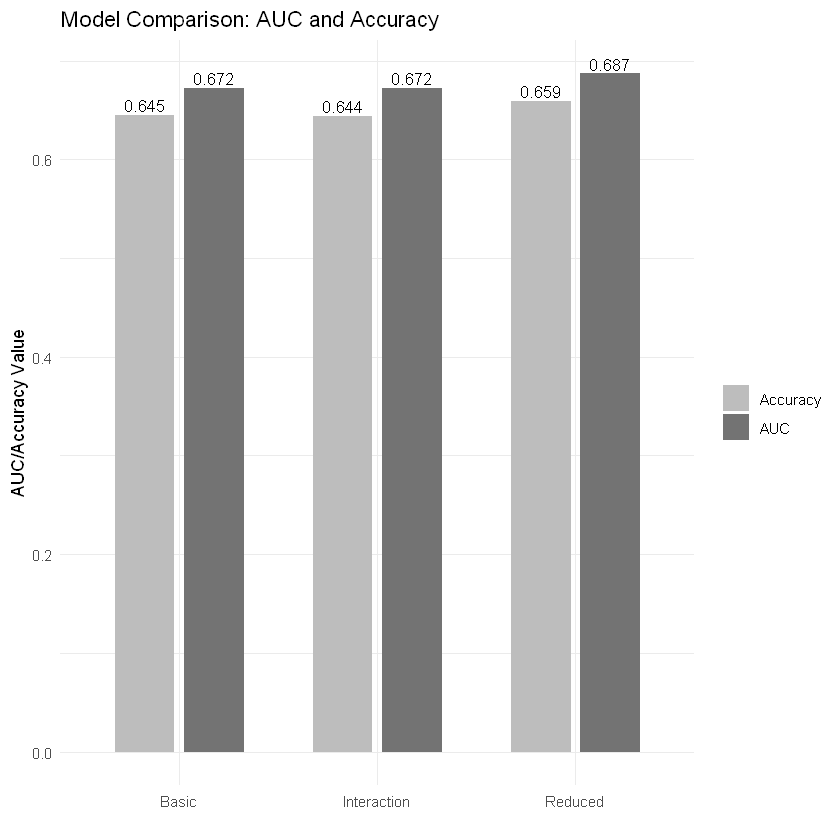

In [23]:
set.seed(1811)


AUC_b <- round(result_basic$AUC[1],3)
ACC_b <- round(result_basic$Accuracy[1],3)

AUC_i <- round(result_interact$AUC[1],3)
ACC_i <- round(result_interact$Accuracy[1],3)

AUC_r <- round(result_reduced$AUC[1],3)
ACC_r <- round(result_reduced$Accuracy[1],3)


metrics <- data.frame(
  Model = c("Basic", "Interaction", "Reduced"),
  AUC = c(AUC_b, AUC_i, AUC_r),
  Accuracy = c(ACC_b, ACC_i, ACC_r)
)

metrics_long <- metrics %>%
  pivot_longer(cols = c(AUC, Accuracy),
               names_to = "Metric",
               values_to = "Value")

ggplot(metrics_long, aes(x = Model, y = Value, fill = Metric)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +
  geom_text(aes(label = round(Value, 3)),
            position = position_dodge(width = 0.7),
            vjust = -0.3, size = 3.5) +
  scale_fill_manual(values = c("AUC" = "#737373", "Accuracy" = "#bdbdbd")) +
  theme_minimal() +
  labs(title = "Model Comparison: AUC and Accuracy",
       y = "AUC/Accuracy Value", x = "") +
  theme(legend.title = element_blank())


### Comparing AUC curves of Basic, Interaction and Interaction_reduced models

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



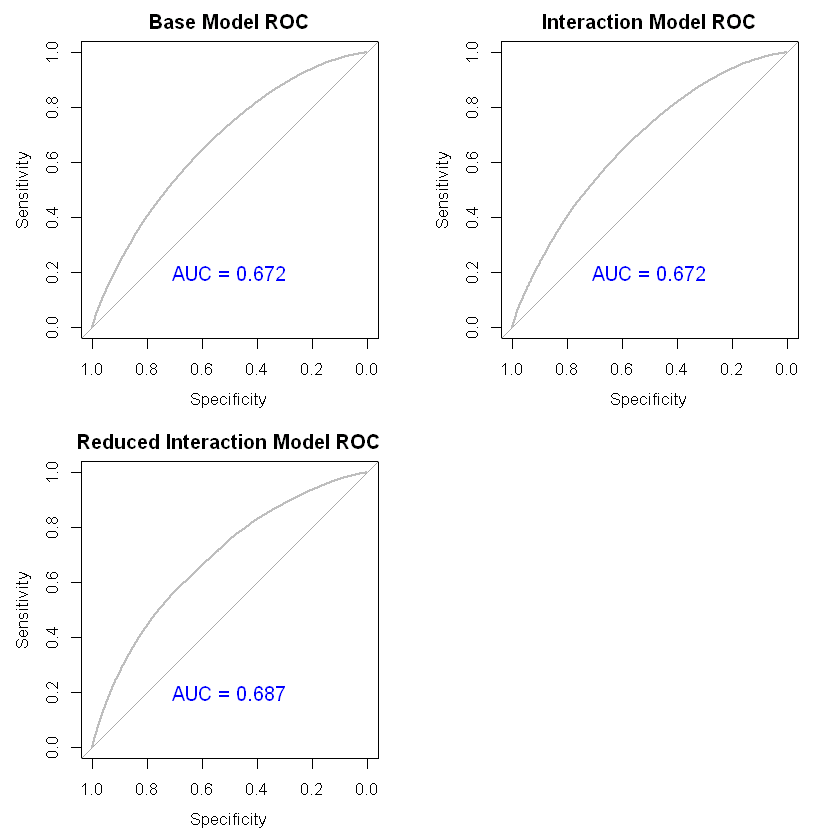

In [17]:
set.seed(1811)
roc1 <- roc(test$is_recid_new, predict(model1, newdata = test, type = "response"))
roc2 <- roc(test$is_recid_new, predict(model_interact, newdata = test, type = "response"))
roc3 <- roc(test$is_recid_new, predict(model_interact_reduced, newdata = test, type = "response"))

par(mfrow = c(2, 2))   # 2 rows, 2 columns
plot(roc1, col = "grey",  lwd = 2, main = "Base Model ROC")
text(0.5, 0.2, paste("AUC =", round(auc(roc1), 3)), col="blue", cex=1.2)
plot(roc2, col = "grey",   lwd = 2, main = "Interaction Model ROC")
text(0.5, 0.2, paste("AUC =", round(auc(roc2), 3)), col="blue", cex=1.2)
plot(roc3, col = "grey", lwd = 2, main = "Reduced Interaction Model ROC")
text(0.5, 0.2, paste("AUC =", round(auc(roc3), 3)), col="blue", cex=1.2)


- Out of the three models, the reduced interaction model performs the best.
- The base model and Interaction model overlap interms of performance. However, the interaction model is better interms of interpreting the socio economic factors and their interactions.

Warning message:
"`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CMU Serif' not found in PostScript font database"
Wa

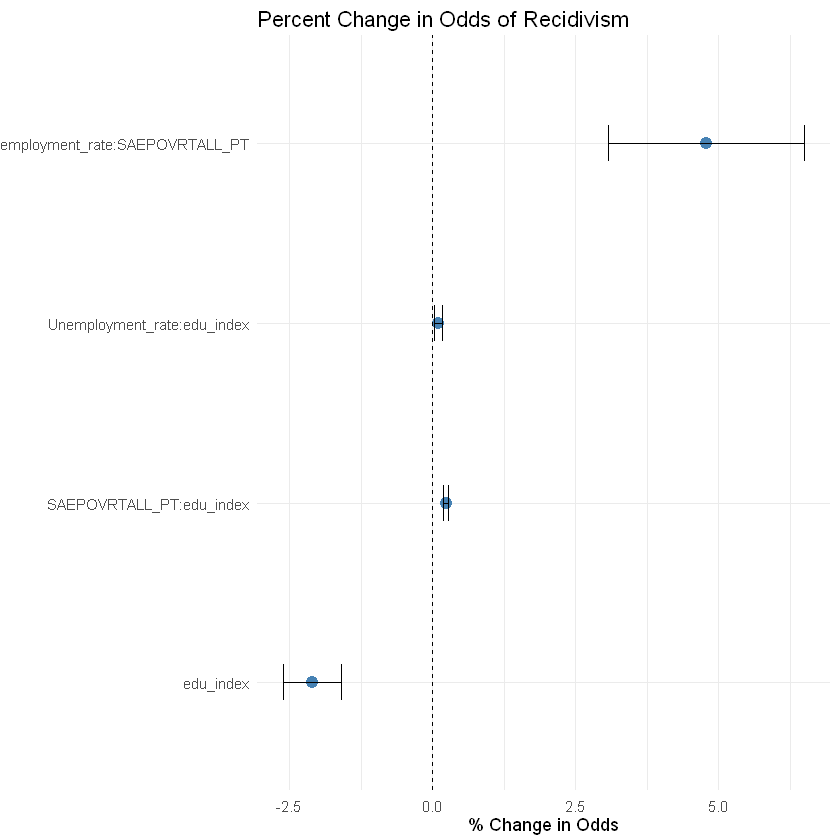

In [67]:
set.seed(1811)
plot_data <- tidy(model_interact_reduced, conf.int=TRUE) %>%
  filter(term %in% c("edu_index",
                     "Unemployment_rate:SAEPOVRTALL_PT",
                     "Unemployment_rate:edu_index",
                     "SAEPOVRTALL_PT:edu_index")) %>%
  mutate(
    odds_pct = (exp(estimate) - 1) * 100,
    conf.low.pct = (exp(conf.low) - 1) * 100,
    conf.high.pct = (exp(conf.high) - 1) * 100
  )

ggplot(plot_data, aes(odds_pct, term)) +
  geom_point(size=3, color="steelblue") +
  geom_errorbarh(aes(xmin=conf.low.pct, xmax=conf.high.pct), height=0.2) +
  geom_vline(xintercept = 0, linetype="dashed") +
  labs(title="Percent Change in Odds of Recidivism",
       x="% Change in Odds", y=NULL) +
  theme_minimal(base_family="CMU Serif")



- This Plot shows the confidence interval of odds% change for each of the socio economic predictors cpmbination.
- Unemployment_rate and Poverty interaction shows the largest change in recidivism where we see an increase in 5%.
- Education by itseld reduces recidivism odds by about 2%.
- Unemployment + Education and Poverty + Education has small but significant change in the odds of recidivism.

edu_quartile,mean_pred
<fct>,<dbl>
Low Education,0.4020179
Medium-Low,0.3912883
Medium-High,0.3716937
High Education,0.4032882


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'CM Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.

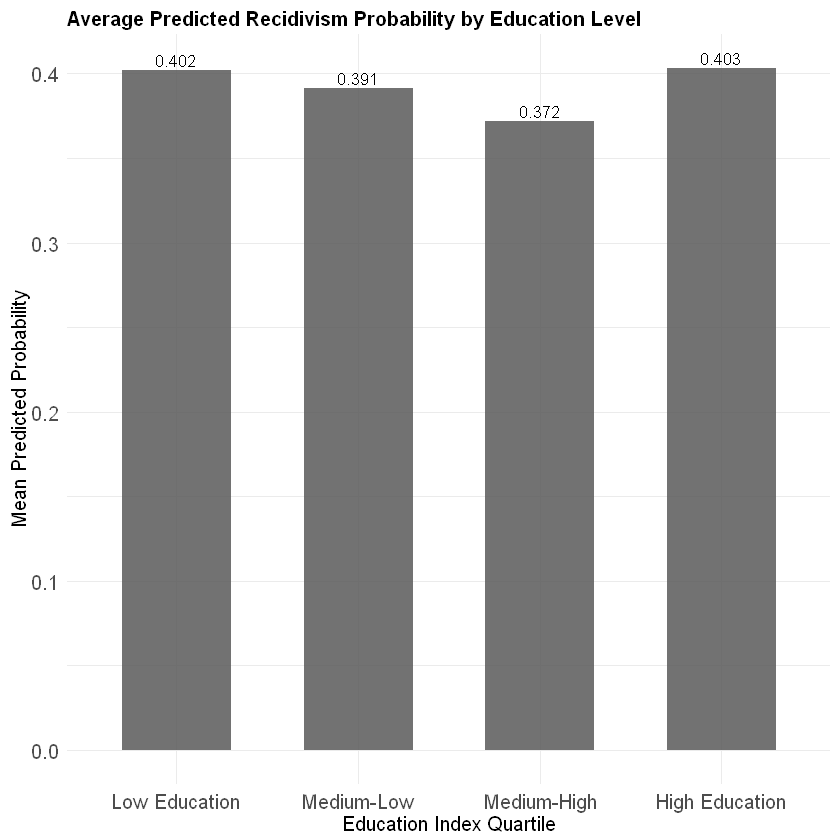

In [68]:
set.seed(1811)

# Dividing eductaion into 4 quantiles
test_edu <- test %>%
  mutate(
    edu_quartile = ntile(edu_index, 4),  # Split into 4 groups
    edu_quartile = factor(
      edu_quartile,
      labels = c("Low Education", "Medium-Low", "Medium-High", "High Education")
    )
  )

# Predicting probabilities for test data and adding it to the same dataframe as we added the quantiles
test_edu$pred_prob <- predict(model_interact_reduced, newdata = test, type = "response")

#Summarize predicted probabilities by education level

edu_summary <- test_edu %>%
  group_by(edu_quartile) %>%
  summarise(mean_pred = mean(pred_prob, na.rm = TRUE))

edu_summary

# Create a Bar plot depicting the probabilties of recidivism by Education level:


ggplot(edu_summary, aes(x = edu_quartile, y = mean_pred)) +
  geom_bar(stat = "identity", width = 0.6, alpha = 0.85) +
  geom_text(aes(label = sprintf("%.3f", mean_pred)), vjust = -0.3, size = 3.5) +
  labs(
    title = "Average Predicted Recidivism Probability by Education Level",
    x = "Education Index Quartile",
    y = "Mean Predicted Probability"
  ) +
  theme_minimal(base_family = "CM Roman") +
  theme(
    plot.title = element_text(face="bold", size=12),
    axis.title = element_text(size=12),
    axis.text  = element_text(size=12)
  )


- Higher education decreases the the probability of recidivism in general. The decrease in odds is about 2% according to the model.
- The sudden increase in mean probabilities of recidivism is probably due to the presence of other socio-economic interactions

### Table of coefficients

In [35]:
set.seed(1811)

tbl <- tidy(model_interact_reduced)[, c("term", "estimate", "std.error", "p.value")]
knitr::kable(
  tbl,
  caption = "Table of Logistic regression coefficients for model predictors."
)




Table: Table of Logistic regression coefficients for model predictors.

|term                                       |   estimate| std.error|   p.value|
|:------------------------------------------|----------:|---------:|---------:|
|(Intercept)                                |  5.2622664| 0.7287175| 0.0000000|
|Unemployment_rate                          | -0.2614376| 0.1036682| 0.0116733|
|SAEPOVRTALL_PT                             | -0.6502037| 0.0607891| 0.0000000|
|edu_index                                  | -0.0213398| 0.0026295| 0.0000000|
|raceAmerican Indian or Alaskan Native      |  0.2815092| 0.0216274| 0.0000000|
|raceAsian or Pacific Islander              | -0.3540519| 0.0448774| 0.0000000|
|raceCaucasian                              | -0.2157736| 0.0115494| 0.0000000|
|raceHispanic                               | -0.2851435| 0.0181525| 0.0000000|
|case_typeFelony                            | -0.2570872| 0.0125290| 0.0000000|
|case_typeMisdemeanor                       | 

In [36]:
set.seed(1811)

results <- tidy(model_interact_reduced)[, c("term", "estimate", "std.error", "p.value")]

results_table <- as.data.frame(results)

results_table <- results_table %>%
mutate(Percent.odds.change = (exp(estimate)-1)*100)

results_table <- results_table %>%
  mutate(across(c(estimate, std.error, p.value, Percent.odds.change),
                ~ round(., 4)))

results_table <- results_table %>%
  mutate(
    across(c(estimate, std.error, p.value, Percent.odds.change),
           round, 4),
    Significance = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      p.value < 0.05  ~ "*",
      TRUE ~ ""
    )
  ) %>%
  rename(
    Term = term,
    Estimate = estimate,
    `Std Error` = std.error,
    `p-value` = p.value,
    `% Odds Change` = Percent.odds.change
  ) %>%
  tibble::as_tibble()

results_table


Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `across(...)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))"


Term,Estimate,Std Error,p-value,% Odds Change,Significance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),5.2623,0.7287,0.0000,19191.8231,***
Unemployment_rate,-0.2614,0.1037,0.0117,-23.0056,*
SAEPOVRTALL_PT,-0.6502,0.0608,0.0000,-47.8061,***
edu_index,-0.0213,0.0026,0.0000,-2.1114,***
raceAmerican Indian or Alaskan Native,0.2815,0.0216,0.0000,32.5128,***
raceAsian or Pacific Islander,-0.3541,0.0449,0.0000,-29.8161,***
raceCaucasian,-0.2158,0.0115,0.0000,-19.4082,***
raceHispanic,-0.2851,0.0182,0.0000,-24.8094,***
case_typeFelony,-0.2571,0.0125,0.0000,-22.6699,***


In [75]:
library(pROC)

auc_basic    <- roc(test$is_recid_new, predict(model1, test, type="response"))
auc_interact <- roc(test$is_recid_new, predict(model_interact, test, type="response"))
auc_reduced  <- roc(test$is_recid_new, predict(model_interact_reduced, test, type="response"))

ci_basic    <- ci.auc(auc_basic)
ci_interact <- ci.auc(auc_interact)
ci_reduced  <- ci.auc(auc_reduced)



comparison_df <- data.frame(
  Model = c(
    "Basic Model (No Interactions)",
    "Interaction Model",
    "Reduced Interaction Model"
  ),
  
  AUC = c(
    round(as.numeric(result_basic$AUC), 3),
    round(as.numeric(result_interact$AUC), 3),
    round(as.numeric(result_reduced$AUC), 3)
  ),
  
  CI = c(
    sprintf("(%.4f, %.4f)", ci_basic[1], ci_basic[3]),
    sprintf("(%.4f, %.4f)", ci_interact[1], ci_interact[3]),
    sprintf("(%.4f, %.4f)", ci_reduced[1], ci_reduced[3])
  ),
  
  Accuracy = c(
    round(as.numeric(result_basic$Accuracy), 3),
    round(as.numeric(result_interact$Accuracy), 3),
    round(as.numeric(result_reduced$Accuracy), 3)
  ),
  
  Sensitivity = c(
    round(as.numeric(result_basic$Sensitivity), 3),
    round(as.numeric(result_interact$Sensitivity), 3),
    round(as.numeric(result_reduced$Sensitivity), 3)
  ),
  
  Specificity = c(
    round(as.numeric(result_basic$Specificity), 3),
    round(as.numeric(result_interact$Specificity), 3),
    round(as.numeric(result_reduced$Specificity), 3)
  )
)

comparison_df
write.csv(comparison_df, "Results.csv", row.names = FALSE)

Setting levels: control = Class0, case = Class1

Setting direction: controls < cases

Setting levels: control = Class0, case = Class1

Setting direction: controls < cases

Setting levels: control = Class0, case = Class1

Setting direction: controls < cases



Model,AUC,CI,Accuracy,Sensitivity,Specificity
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Basic Model (No Interactions),0.672,"(0.6688, 0.6751)",0.645,0.366,0.826
Interaction Model,0.672,"(0.6684, 0.6747)",0.644,0.362,0.827
Reduced Interaction Model,0.687,"(0.6837, 0.6899)",0.659,0.334,0.869


In [37]:
write.csv(results_table, "Coeff_table.csv", row.names = FALSE)

## 7. Takeaways

- Socio-economic factors, especially their interaction terms have a statistically significant influence on recidivism. Although the effects are small, they do influence recidivism which is evident from the Wald's test.
- Unemployment and Poverty combined have the most influence when compared to other factors with a 5% increase in recidivism.
- The marginal effect of Unemployment and Poverty says that recidivism decreases as poverty and unemployment increases. This may be counter intuitive and due to the presence of other socio economic factors.
- The addition of education to unemployment and Poverty terms seems to be reducing the effect of both to 0.1 and 0.24% respectively.
- The three-way interaction term suggests the same. Education mitigates the effect of Unemployment and Poverty by reducing recidivism by about 0.2%.
- Significant racial disparities exist in the model, although the model does not test causality.
- The most dominating factors seems to be prior history(15% increase in recidivism), jail time, case type with age group under 25 being the highest contributor of recidivism (76% odds change) as found in the EDA.